## 2. Random forest for classification and regression

a) Use random forest to classify the iris dataset and evaluate afterwards

b) Use random forest to predict house prices for the dataset you used in exercise1 

## a) Use random forest to classify the iris dataset and evaluate afterwards

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["iris_class"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
X, y = df.drop("iris_class", axis=1), df["iris_class"]
X.shape, y.shape

((150, 4), (150,))

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((100, 4), (50, 4))

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10] - y_test[:10].values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



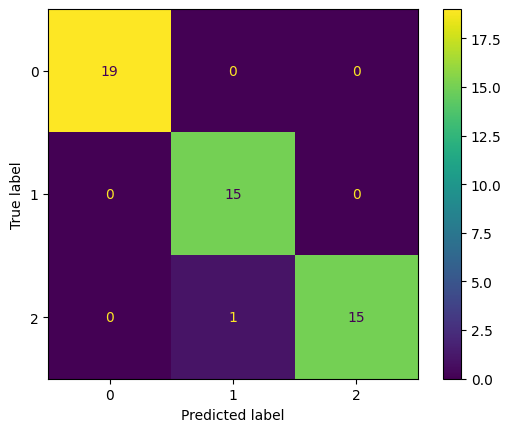

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

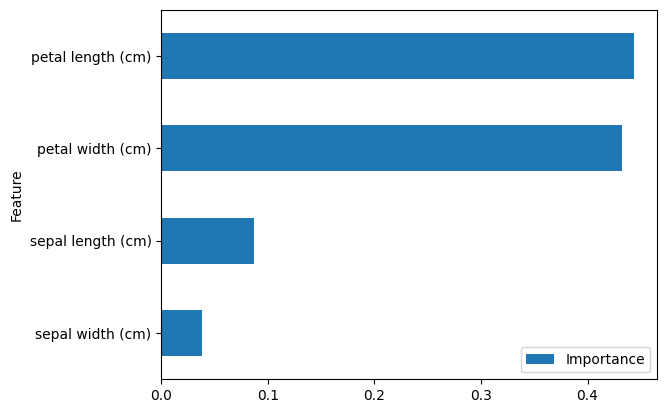

In [9]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]
feature_importance = feature_importance.sort_values(by= "Importance", ascending=False)
ax = feature_importance.plot(x="Feature", y="Importance", kind="barh")
ax.invert_yaxis()

## b) Use random forest to predict house prices for the dataset you used in exercise1 

In [10]:
df = pd.read_csv("../../data/house_data.csv")
df = df.query("price > 0")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [11]:
df.drop(["date", "street", "city", "statezip", "country"], axis=1, inplace=True)

In [12]:
X, y = df.drop("price", axis=1), df["price"]
X.shape, y.shape

((4551, 12), (4551,))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((3049, 12), (1502, 12))

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10]

array([1277179.5       ,  571594.05      ,  693745.5       ,
        257468.72733333,  561517.74      ,  428617.5420833 ,
        351826.91666667,  260207.28999999,  456155.72      ,
        689903.5984483 ])

In [22]:
y_test[:10].values

array([1225000.,  496752.,  612500.,  265000.,  615000.,  432000.,
        305000.,  405000.,  349000.,  839000.])

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"{mae = }")
print(f"{mse = }")
print(f"{rmse = }")

mae = 161558.3872783091
mse = 86451333494.14778
rmse = 294026.0762145898
